## Movies Dataset 2024 - Grupo 9
<hr style="border:1px solid gray">

In [2]:
# To run with uv
uv init
uv sync
uv run jupyter lab

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import kagglehub
from scipy import stats as st
from scipy.stats import describe

#### Importamos el dataset
---

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

Path to dataset files: /Users/nicolastonnelier/.cache/kagglehub/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/875


#### Funciones auxiliares (helper functions)



In [4]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
    plt.axvline(media, color='red', linestyle='--', label='Media')
    if mvd:
        plt.figtext(0.15, 0.8, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var: {var:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std: {std:.2f}', fontsize=10, color='red')
    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

#### Descripción del dataset IMDB Movies 2024


| Variable              | Descripción                                                                                  |
|-----------------------|----------------------------------------------------------------------------------------------|
| `id`                  | Unique identifier for each movie. (type: int)                                                |
| `title`               | Title of the movie (usually in English or the display title). (type: str)                    |
| `vote_average`        | Average vote or rating given by viewers (typically 0–10 scale). (type: float)                |
| `vote_count`          | Total count of votes received for the movie. (type: int)                                     |
| `status`              | Current status of the movie (Released, Rumored, Post Production, etc.). (type: str)          |
| `release_date`        | Date when the movie was released (format usually YYYY-MM-DD). (type: str)                    |
| `revenue`             | Total revenue generated by the movie (in USD; 0 often means unknown/missing). (type: int)    |
| `runtime`             | Duration of the movie in minutes (0 usually means unknown). (type: int)                      |
| `adult`               | Indicates if the movie is only for adult audiences (true/false). (type: bool)                |
| `backdrop_path`       | Relative path to the backdrop image for the movie . (type: str)                              |
| `budget`              | Estimated production budget of the movie (USD; 0 often means unknown/missing). (type: int64) |
| `homepage`            | Official website URL of the movie (empty string or null if not available). (type: str)       |
| `imdb_id`             | IMDb identifier for the movie (format: tt followed by 7–8 digits). (type: str)               |
| `original_language`   | ISO 639-1 code of the original language of the movie (e.g., 'en', 'fr', 'es'). (type: str)   |
| `original_title`      | Original title of the movie (in its original language). (type: str)                          |
| `overview`            | Brief plot summary or synopsis of the movie. (type: str)                                     |
| `popularity`          | Popularity score assigned by TMDB (higher = more popular). (type: float64)                   |
| `poster_path`         | Relative path to the poster image for the movie (prepend https://image.tmdb.org) (type: str) |
| `tagline`             | Short marketing tagline or slogan of the movie (often empty). (type: str)                    |
| `genres`              | List of genres (usually as comma-separated string or JSON in some datasets). (type: str)     |
| `production_companies`| Name(s) of the main production company/companies (often comma-separated or JSON) (type: str) |
| `production_countries`| Country/countries where the movie was produced (often comma-separated or JSON). (type: str)  |
| `spoken_languages`    | Language(s) spoken in the movie (comma-separated or JSON. ISO codes and names). (type: str)  |
| `keywords`            | Descriptive keywords/tags linked with the movie (often comma-separated or JSON). (type: str) |

In [5]:
# Cargamos el dataset
from pathlib import Path

csv_file = next(Path(path).glob("*.csv"))
movies = pd.read_csv(csv_file)

#### Primera inspección
<hr style="border:1px solid gray">

In [28]:
print(f"Dimensiones del dataset original: {movies.shape}")
# exclude columns w/o valuable data (e.g. backdrop_path, imdb_id,..)
columns = ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'keywords']
movies[columns].head()

Dimensiones del dataset original: (1386347, 24)


,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_companies,production_countries,keywords
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,..."
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f..."
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ..."
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"new york city, superhero, shield, based on com..."


In [10]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1385673 entries, 0 to 1385672
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1385673 non-null  int64  
 1   title                 1385655 non-null  str    
 2   vote_average          1385673 non-null  float64
 3   vote_count            1385673 non-null  int64  
 4   status                1385673 non-null  str    
 5   release_date          1087157 non-null  str    
 6   revenue               1385673 non-null  int64  
 7   runtime               1385673 non-null  int64  
 8   adult                 1385673 non-null  bool   
 9   backdrop_path         346888 non-null   str    
 10  budget                1385673 non-null  int64  
 11  homepage              142939 non-null   str    
 12  imdb_id               660886 non-null   str    
 13  original_language     1385673 non-null  str    
 14  original_title        1385655 non-null  str  

In [29]:
movies[columns].describe()

,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.386347e+06,1.386347e+06,1.386347e+06,1.386347e+06,1.386347e+06,1.386347e+06
mean,1.586601e+00,1.547717e+01,6.251940e+05,4.434804e+01,2.394681e+05,1.034936e+00
std,2.875729e+00,2.884933e+02,1.922401e+07,6.077344e+01,5.101511e+06,6.884415e+00
min,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,2.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.300000e-01
max,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


## Análisis de las variables numéricas
<hr style="border:1px solid gray">


#### Max/Mins

In [15]:
# Maximum budget
max_budget = movies['budget'].max()
print(f"Maximum budget: ${max_budget:,}")

# Minimum budget
min_budget = movies['budget'].min()
print(f"Minimum budget: ${min_budget:,}")

# Maximum revenue
max_budget = movies['revenue'].max()
print(f"Maximum revenue: ${max_budget:,}")

# Minimum revenue
min_budget = movies['revenue'].min()
print(f"Minimum revenue: ${min_budget:,}")

# Maximum popularity
max_budget = movies['popularity'].max()
print(f"Maximum popularity: {max_budget:,}")

# Minimum popularity
min_budget = movies['popularity'].min()
print(f"Minimum popularity: {min_budget:,}")

Maximum budget: $999,999,999
Minimum budget: $0
Maximum revenue: $4,999,999,999
Minimum revenue: $-12
Maximum popularity: 2,994.357
Minimum popularity: 0.0


#### Histogramas

In [13]:
# format large values for human readab ility
def human_format_K(num, pos=None):
    """
    Format numbers nicely with K.
    
    Examples:
    - human_format_K(4500)          → '4.5K'
    - human_format_K(4500000)       → '4500K'
    """
    if num == 0:
        return "0"
    
    else:
        value = num / 1_000.0
        suffix = 'K'
        # For thousands: usually whole number unless very small
        fmt = ".1f" if value < 10 else ".0f"
    
    return f"{value:{fmt}}{suffix}"

# format to Million
def human_format_M(num, pos=None):
    """
    Format numbers nicely with M.
    
    Examples:
    - human_format_M(4500000) → '4.5M'
    """
    if num == 0:
        return "0"
    
    else:
        # Force million scale
        value = num / 1_000_000.0
        suffix = 'M'
        # Show one decimal if < 10M, otherwise whole number
        fmt = ".1f" if value < 10 else ".0f"
    
    return f"{value:{fmt}}{suffix}"

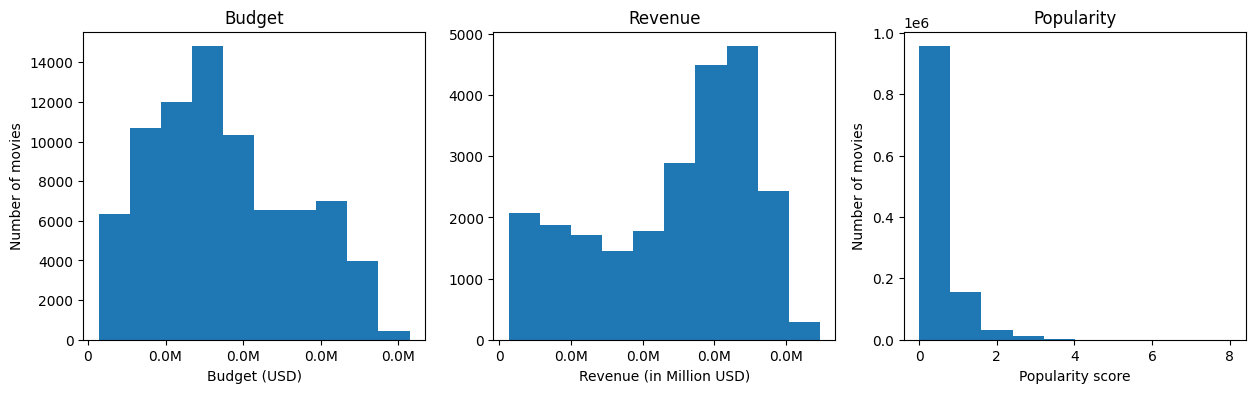

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# --- Budget ---
valid_budget = movies['budget'].replace(0, np.nan)
ax[0].hist(np.log1p(valid_budget)) # using log to compress large values
ax[0].set_title('Budget')
ax[0].set_xlabel('Budget (USD)')
ax[0].set_ylabel('Number of movies')
ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(human_format_M))

# --- Revenue ---
valid_revenue = movies['revenue'].replace(0, np.nan)
ax[1].hist(np.log1p(valid_revenue)) # using log to compress large values
ax[1].set_title('Revenue')
ax[1].set_xlabel('Revenue (in Million USD)')
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(human_format_M))

# --- Popularity ---
valid_pop = movies['popularity'].replace(0, np.nan)
ax[2].hist(np.log1p(valid_pop)) # using log to compress large values
ax[2].set_title('Popularity')
ax[2].set_xlabel('Popularity score')
ax[2].set_ylabel('Number of movies')

plt.show()

### Movies per month
<hr style="border:1px solid gray">


Standarize dates:

In [49]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

Visualize:

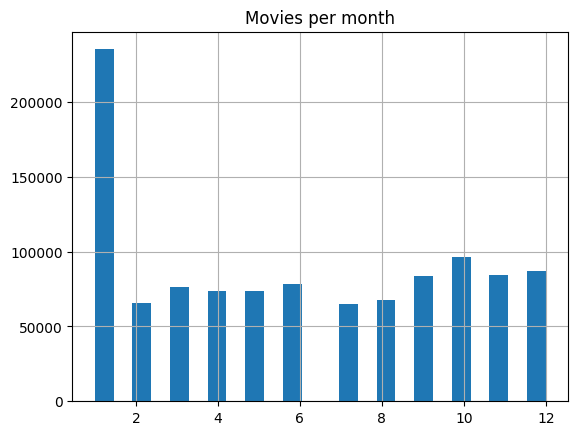

In [57]:
movies['release_month'] = movies['release_date'].dt.month
ax = movies['release_month'].hist(bins=24)
ax.set_title('Movies per month')
plt.show()

### 1. Medidas de tendencia central: media, mediana y moda
<hr style="border:1px solid gray">


#### Media

In [59]:
np.mean(movies['budget'])    # Budget

np.float64(239468.07400744548)

In [61]:
np.mean(movies['revenue']) # Revenue

np.float64(625194.0062011891)

In [63]:
np.mean(movies['popularity']) # Popularity

np.float64(1.0349363535556808)

#### Mediana

In [18]:
np.median(movies['budget'])  # Budget

np.float64(0.0)

In [20]:
np.median(movies['revenue']) # Revenue

np.float64(0.0)

In [70]:
np.median(movies['popularity']) # Popularity

np.float64(0.6)

#### Moda

In [41]:
movies['budget'].mode()[0]     # Budget

np.int64(0)

In [72]:
mode_age = st.mode(movies['budget'], keepdims=False)  # con SciPy (no funciona con nulos)
mode_age.mode

np.int64(0)

In [40]:
movies['revenue'].mode()[0]     # Revenue

np.int64(0)

In [24]:
movies['popularity'].mode()[0]     # Popularity

np.float64(0.6)

#### Por qué Moda y Mediana de 0 para budget y revenue?
Hay muchos 0s. IMDB usa el 0 para representar "unknown", no el valor 0.

In [7]:
(movies['budget'] == 0).sum()

np.int64(1307741)

In [8]:
(movies['revenue'] == 0).sum()

np.int64(1362550)

In [9]:
(movies['budget'] == 0).mean()

np.float64(0.9432999097628516)

In [10]:
(movies['revenue'] == 0).mean()

np.float64(0.9828347448366102)

In [38]:
movies['budget'].replace(0, np.nan).mode()[0]     # moda Budget excluyendo 0s

np.float64(100.0)

In [39]:
movies['revenue'].replace(0, np.nan).mode()[0]     # moda Revenue excluyendo 0s

np.float64(1.0)